In [1]:
import matplotlib.pyplot as plt
import numpy as np
import synphot.units
from synphot import Observation

from hispecfib.lightpath import *
import hispecfib.throughput_helper as th
import astropy.units as u

excel = '/Users/jibailey/src/hispec-fib/hispecfib/HISPEC_throughputs.xlsx'
data_dir = '/Users/jibailey/Library/CloudStorage/OneDrive-CaliforniaInstituteofTechnology/HISPEC/HISPEC - Systems Engineering [L2]/HISPEC - Performance Budgets/Optical transmission budget/Excel Throughput Code/inputs'

Excluding row 49 due to 'qe' in Name qe.


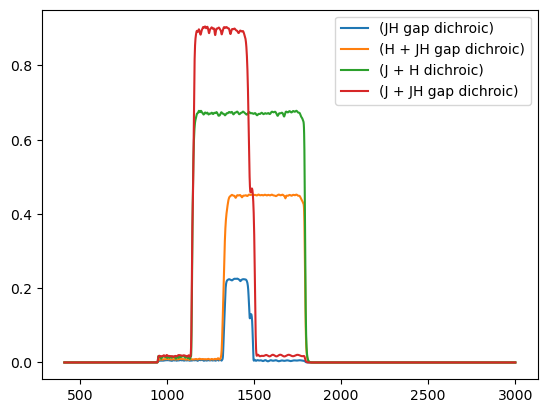

In [2]:
ab_trans=th.section_transmissions(excel, path_to_data=data_dir)
ATC_MODE_TRANS = th.section_transmissions(excel, 'FEI ATC', exclude='QE', all_modes=True, path_to_data=data_dir)
for i,(k,(w,t)) in enumerate(ATC_MODE_TRANS.items()):
    plt.plot(w,t*(i+1)/4,label=k)
plt.legend()

In [3]:
AO_PREOPTIC_TRANS = th.section_transmissions(excel, 'AO', path_to_data=data_dir)
FEI_PREOPTIC_TRANS = th.section_transmissions(excel, 'FEI COMMON', path_to_data=data_dir)

ATC_MODE_TRANS = th.section_transmissions(excel, 'FEI ATC', exclude='QE', all_modes=True, path_to_data=data_dir)

ATC_TRANS_NO_DICH = th.section_transmissions(excel, 'FEI ATC', exclude=['QE', 'ATC Dichroic'], path_to_data=data_dir)
ATC_DICH_REFLECTION = th.section_transmissions(excel, 'FEI ATC', names=['ATC Dichroic'], all_modes=True, path_to_data=data_dir)
ATC_AR = th.section_transmissions(excel, 'FEI BLUE', path_to_data=data_dir, names=['ATC Dichroic AR Coating'])

ATC_DICH_TRANSMISSION_AND_AR = th.section_transmissions(excel, 'FEI BLUE', names=['ATC Dichroic', 'ATC Dichroic AR Coating'],
                                                        all_modes=True, path_to_data=data_dir)
FEI_YJ_TRANS_PIAA_ONLY = th.section_transmissions(excel, 'FEI BLUE', names=['PIAA Lenses', 'PIAA AR Coating Surf 1',
                                                                            'PIAA AR Coating Surf 2', 'PIAA AR Coating Surf 3',
                                                                            'PIAA AR Coating Surf 4'], path_to_data=data_dir)
FEI_YJ_TRANS_NPIAA_NATC = th.section_transmissions(excel, 'FEI BLUE', exclude=['PIAA', 'atc'], path_to_data=data_dir)


FEI_HK_TRANS_PIAA_ONLY = th.section_transmissions(excel, 'FEI RED', names=['PIAA Lenses', 'PIAA AR Coating Surf 1',
                                                                           'PIAA AR Coating Surf 2', 'PIAA AR Coating Surf 3',
                                                                           'PIAA AR Coating Surf 4'], path_to_data=data_dir)
FEI_HK_TRANS_NPIAA_NATC = th.section_transmissions(excel, 'FEI RED', exclude=['PIAA', 'atc'], path_to_data=data_dir)


x = th.make_common_grid([ATC_AR, ATC_DICH_REFLECTION, ATC_DICH_TRANSMISSION_AND_AR, ATC_TRANS_NO_DICH])
ATC_AR, ATC_DICH_REFLECTION, ATC_DICH_TRANSMISSION_AND_AR, ATC_TRANS_NO_DICH = x

# ATC Dichroic and on to ATC, backwards after CSD
RETRO = 1
ATC_REVERSE_MODE_TRANS = {}
ATC_REVERSE_GHOST_MODE_TRANS = {}
ATC_COMBINED_REVERSE_MODE_TRANS = {}
wl_grid = ATC_AR[0]
for k in ATC_DICH_TRANSMISSION_AND_AR:
    #YJ&HK: atc_ar_trans**2 * atc_dich_refl * retro * atc_ar_trans * ATC_dich_tras * rest_of_atc_chain
    net_trans = ATC_AR[1]**2*ATC_DICH_REFLECTION[k][1]*RETRO*ATC_DICH_TRANSMISSION_AND_AR[k][1]*ATC_TRANS_NO_DICH[1]
    ATC_REVERSE_MODE_TRANS[k] = wl_grid, net_trans

    #HK&YJ: atc_ar_refl * retro * atc_ar_trans * ATC_dich_tras * rest_of_atc_chain
    net_trans_ghost = (1-ATC_AR[1])*RETRO*ATC_DICH_TRANSMISSION_AND_AR[k][1]*ATC_TRANS_NO_DICH[1]
    ATC_REVERSE_GHOST_MODE_TRANS[k] = wl_grid, net_trans_ghost  # Ghost doesn't see in reflection
    ATC_COMBINED_REVERSE_MODE_TRANS[k] = wl_grid, (net_trans_ghost+net_trans).clip(0,1)


# FOCUS_COUPLING = th.section_transmissions(excel, 'COUPLING PERFECT', path_to_data=data_dir)

OFS_FIBER = th.section_transmissions(excel, 'FIBER TRANSMISSION BLUE', path_to_data=data_dir)
ZBLAN_FIBER = th.section_transmissions(excel, 'FIBER TRANSMISSION RED', path_to_data=data_dir)

OFS_FIBER_TIB = th.section_transmissions(excel, 'TIB NAS TRANSMISSION BLUE', path_to_data=data_dir, force_include=True)
ZBLAN_FIBER_TIB = th.section_transmissions(excel, 'TIB NAS TRANSMISSION RED', path_to_data=data_dir, force_include=True)

BSPEC_TC = th.section_transmissions(excel, 'BSPEC', exclude='QE', path_to_data=data_dir)
RSPEC_TC = th.section_transmissions(excel, 'RSPEC', exclude='QE', path_to_data=data_dir)

Excluding row 49 due to 'qe' in Name qe.
Excluding row 43 due to 'atc dichroic' in Name atc dichroic.
Excluding row 49 due to 'qe' in Name qe.
Excluding row 51 due to 'atc' in Name atc dichroic.
Excluding row 52 due to 'atc' in Name atc dichroic ar coating.
Excluding row 54 due to 'piaa' in Name piaa lenses.
Excluding row 55 due to 'piaa' in Name piaa ar coating surf 1.
Excluding row 56 due to 'piaa' in Name piaa ar coating surf 2.
Excluding row 57 due to 'piaa' in Name piaa ar coating surf 3.
Excluding row 58 due to 'piaa' in Name piaa ar coating surf 4.
Excluding row 69 due to 'atc' in Name atc dichroic.
Excluding row 70 due to 'atc' in Name atc dichroic ar coating.
Excluding row 73 due to 'piaa' in Name piaa lenses.
Excluding row 74 due to 'piaa' in Name piaa ar coating surf 1.
Excluding row 75 due to 'piaa' in Name piaa ar coating surf 2.
Excluding row 76 due to 'piaa' in Name piaa ar coating surf 3.
Excluding row 77 due to 'piaa' in Name piaa ar coating surf 4.
Excluding row 122 d

In [4]:
def db2trans(db):
    return 10**-(db/10)

FREESPACE_COUPLING = .75

POWER_SPLITTER_OUTPUT_FRACTION = (.2485+.2533+.2533+.2449)/4
SMF_2_MMF_COUPLING = .8

WDM_YJ_PS1_TRANS = ([900, 1028, 1270, 1430, 1510, 2330, 2600],
                    [.3,
                     db2trans((5.23+4.83+6.35+4.22)/4),
                     db2trans((6.90+6.55+6.38+7.03)/4),
                     db2trans((6.46+6.37+6.26+6.58)/4),
                     db2trans((6.41+6.46+6.53+6.63)/4),
                     db2trans((9.67+15.21+15.20+19.78)/4),
                     0])


## Placeholder
WDM_HK_TRANS = ([900, 1028, 1270, 1430, 1510, 2330, 2600], [.25, .25, .25, .25, .25, .25, .25])

lp = build_hispec_partial()

# Fiber transmissions and couplings
lp.get('fib_yj_retro').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_retro').coupling = FREESPACE_COUPLING*POWER_SPLITTER_OUTPUT_FRACTION
lp.get('fib_yj_smf_pd').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_smf_pd').coupling = FREESPACE_COUPLING*SMF_2_MMF_COUPLING
lp.get('fib_yj_ao').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_ao').coupling = FREESPACE_COUPLING
lp.get('fib_yj_fei').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER_TIB)
lp.get('fib_yj_fei').coupling = FREESPACE_COUPLING
lp.get('fib_yj_science').transmission = TransmissionCurve.from_tabulated(*OFS_FIBER)
lp.get('fib_yj_science').coupling = FREESPACE_COUPLING

lp.get('fib_hk_retro').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_retro').coupling = FREESPACE_COUPLING*POWER_SPLITTER_OUTPUT_FRACTION
lp.get('fib_hk_smf_pd').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_smf_pd').coupling = FREESPACE_COUPLING*SMF_2_MMF_COUPLING
lp.get('fib_hk_ao').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_ao').coupling = FREESPACE_COUPLING
lp.get('fib_hk_fei').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER_TIB)
lp.get('fib_hk_fei').coupling = FREESPACE_COUPLING
lp.get('fib_hk_science').transmission = TransmissionCurve.from_tabulated(*ZBLAN_FIBER)
lp.get('fib_hk_science').coupling = FREESPACE_COUPLING

lp.get('jumper_1028').coupling = db2trans(1.42)
lp.get('jumper_1270').coupling = db2trans(0.56)
lp.get('jumper_1430_yj').coupling = db2trans(.39)
lp.get('jumper_1510').coupling = db2trans(4.36)
lp.get('jumper_2330').coupling = db2trans(5.13)
lp.get('jumper_1430_hk').coupling = db2trans(3.3)

# Pre ATC Dichroic Losses
lp.get('ao_losses').t_AB = TransmissionCurve.from_tabulated(*AO_PREOPTIC_TRANS)
lp.get('fei_pre_losses').t_AB = TransmissionCurve.from_tabulated(*FEI_PREOPTIC_TRANS)

# ATC Dichroic and on to ATC, forward
lp.get('atc_dichroic_selector')._models['JHgap'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['JH'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(J + H dichroic)'])
lp.get('atc_dichroic_selector')._models['H'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(H + JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['J'][('A','B')] = TransmissionCurve.from_tabulated(*ATC_MODE_TRANS['(J + JH gap dichroic)'])

# ATC Dichroic to CSD, forward
lp.get('atc_dichroic_selector')._models['JHgap'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['JH'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(J + H dichroic)'])
lp.get('atc_dichroic_selector')._models['H'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(H + JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['J'][('A','C')] = TransmissionCurve.from_tabulated(*ATC_DICH_TRANSMISSION_AND_AR['(J + JH gap dichroic)'])

# ATC Dichroic and on to ATC, backwards after CSD
lp.get('atc_dichroic_selector')._models['JHgap'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['JH'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(J + H dichroic)'])
lp.get('atc_dichroic_selector')._models['H'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(H + JH gap dichroic)'])
lp.get('atc_dichroic_selector')._models['J'][('C','B')] = TransmissionCurve.from_tabulated(*ATC_COMBINED_REVERSE_MODE_TRANS['(J + JH gap dichroic)'])

# CSD and on to foci, excluding piaa or fiber coupling
lp.get('csd').curves[('A','B')] = TransmissionCurve.from_tabulated(*FEI_YJ_TRANS_NPIAA_NATC)
lp.get('csd').curves[('A','C')] = TransmissionCurve.from_tabulated(*FEI_HK_TRANS_NPIAA_NATC)
lp.get('csd').curves[('B','A')] = TransmissionCurve.from_tabulated(*FEI_YJ_TRANS_NPIAA_NATC)
lp.get('csd').curves[('C','A')] = TransmissionCurve.from_tabulated(*FEI_HK_TRANS_NPIAA_NATC)

lp.get('selector_yj_piaa')._models['piaa'] = TransmissionCurve.from_tabulated(*FEI_YJ_TRANS_PIAA_ONLY)
lp.get('selector_hk_piaa')._models['piaa'] = TransmissionCurve.from_tabulated(*FEI_HK_TRANS_PIAA_ONLY)

# TIB Components
lp.get('wdm_yj').per_input = 3*[TransmissionCurve.from_tabulated(*WDM_YJ_PS1_TRANS)]
lp.get('wdm_hk').per_input = 3*[TransmissionCurve.from_tabulated(*WDM_HK_TRANS)]

In [5]:
s_1028 = lp.get("LD1028")
s_1270 = lp.get("LD1270")
s_1430_yj = lp.get("LD1430_yj")
s_1430_hk = lp.get("LD1430_hk")
s_1510 = lp.get("LD1510")
s_2330 = lp.get("LD2330")

atc = lp.get("ATC")
rspec = lp.get("RSPEC")
bspec = lp.get("BSPEC")

pd_yj = lp.get("pd_yj")
pd_hk = lp.get("pd_hk")

att_1028 = lp.get("att_1028")
att_1270 = lp.get("att_1270")
att_1430_yj = lp.get("att_1430_yj")
att_1430_hk = lp.get("att_1430_hk")
att_1510 = lp.get("att_1510")
att_2330 = lp.get("att_2330")

In [6]:
# att_1028.set_db(73)
# att_1270.set_db(40)
# att_1430_yj.set_db(90)
# att_1430_hk.set_db(90)
# att_1510.set_db(33)
# att_2330.set_db(0)
#
# lp.get("atc_dichroic_selector").set_state("JHgap")
# lp.get("selector_yj_focus").set_state("SMF")
# lp.get("selector_hk_focus").set_state("MMF")
#
# # Retro switch (YJ): 1‑in → 2‑out
# lp.get("sw21_yj_retro").set_state('C','A')  # CA:Forward CB:Retro
#
# # FEI feed switch: 1→2
# lp.get("sw25_yj_fei").set_state('C','B')  # CA: AO CB: FEI
#
# # PD branch: 2→1
# lp.get("sw27_yj_pd").set_state('A','C')  #AC: SMF BC: MMF
# x = lp.find_all_paths(s_1430_yj.port("out"), pd_yj.port("in"))
# pc  = lp.path_curve(x[0])
#
# ss=SourceSpectrum(synmodels.Gaussian1D, amplitude=6.583412854219877e+20, mean=1430.024*u.nm, stddev=5.79326831967524e-06*u.nm)
# samp_wave = np.arange(1425,1435, 5e-6)*u.nm
# print((ss(samp_wave)[:-1]*u.cm**2*np.diff(samp_wave)).to('ph/s').sum())
# spectra = lp.propagate({s_1430_yj.port("out"): s_1430_yj.spectrum()}, [pd_yj, pd_hk, atc])
# s = spectra[pd_yj]
# ss = s.ss
# samp_wave = np.arange(1425,1435,5e-6)*u.nm
# print((ss(samp_wave)[:-1]*u.cm**2*np.diff(samp_wave)).to('ph/s').sum())
# watts = (spectra[pd_yj](samp_wave, photons=True)*(const.h * const.c / (samp_wave).to(u.m))/u.s).to('fW')
# print(watts.max())
# print(pd_yj.observe(spectra[pd_yj], grid_nm=np.arange(1425,1435,spectra[pd_yj].width_hint_nm.value), texp_s=1).signal)

In [16]:
# ### Anticipated Static Attenuation Chains
# - 1028: -90.0 to -73.0 dB, range 17.0 dB, **static -73.0 dB**
# - 1270:  -70.0 to -40.0 dB, range 30.0 dB, **static -40.0 dB**
# - 1430: range 0.0 dB, **static -100.0 dB**
# - 1510: -80.0 to -33.0 dB, range 47.0 dB, **static -33.0 dB**
# - 2330: -73.0 to -3.0 dB, range 70.0 dB, **static -3.0 dB**

att_1028.set_db(73)
att_1270.set_db(40)
att_1430_yj.set_db(90)
att_1430_hk.set_db(90)
att_1510.set_db(33)
att_2330.set_db(3)

lp.get("atc_dichroic_selector").set_state("JHgap")
lp.get("selector_yj_focus").set_state("SCI")  #SMF MMF SCI
lp.get("selector_hk_focus").set_state("SMF")
lp.get('selector_yj_piaa').set_state('vortex_dark')
lp.get('selector_hk_piaa').set_state('vortex_dark')

# Retro switch (YJ): 1‑in → 2‑out
lp.get("sw21_yj_retro").set_state('C','A')  # CA:Forward CB:Retro
lp.get("sw22_hk_retro").set_state('C','A')  # CA:Forward CB:Retro

# FEI feed switch: 1→2
lp.get("sw25_yj_fei").set_state('C','B')  # CA: AO CB: FEI
lp.get("sw26_hk_fei").set_state('C','B')  # CA: AO CB: FEI

# PD branch: 2→1
lp.get("sw27_yj_pd").set_state('A','C')  #AC: SMF BC: MMF
lp.get("sw28_hk_pd").set_state('A','C')  #AC: SMF BC: MMF

src_map = {
    # s_1028.port("out"): s_1028.spectrum(),
    # s_1270.port("out"): s_1270.spectrum(),
    # s_1430_yj.port("out"): s_1430_yj.spectrum(),
    # s_1430_hk.port("out"): s_1430_hk.spectrum(),
    # s_1510.port("out"): s_1510.spectrum(),
    s_2330.port("out"): s_2330.spectrum(),
}
spectra_at_detectors = lp.propagate(src_map, [pd_yj, pd_hk, atc, rspec, bspec])
obs = {}
print(spectra_at_detectors)
for d in spectra_at_detectors:
    spec = spectra_at_detectors[d]
    if spec is None:
        continue
    samp_wave = np.arange(900,2600, spec.width_hint_nm.value)*u.nm
    obs[d]=d.observe(spec, grid_nm=samp_wave, texp_s=.05)
# plt.plot(obs[rspec][62].sn())

0.7750000000000001 mW 9091819031967692.0 3.112899012056289e+17 2330.375 0.011651875
{<Photodiode pd_yj>: None, <Photodiode pd_hk>: <hispecfib.lightpath.Spectrum object at 0x326d151d0>, <Imager ATC>: <hispecfib.lightpath.Spectrum object at 0x326d2c690>, <Spectrograph RSPEC>: None, <Spectrograph BSPEC>: <hispecfib.lightpath.Spectrum object at 0x326d54d10>}
<hispecfib.lightpath.Spectrum object at 0x326d54d10> with mean wavelength of 2330.375000 nm not found in any order in <Spectrograph BSPEC>


In [36]:
v = np.array([0, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25])

atten= np.array([[3.49, 3.49, 3.50, 3.50, 3.54, 3.65, 3.98, 4.70, 6.40, 10.62, 19.48, 33.63, 46.855],
                 [1.17, 1.19, 1.21, 1.24, 1.33, 1.53, 2.04, 3.27, 6.19, 12.04, 21.89, 36.26, 46.855],
                 [0.72, 0.73, 0.75, 0.79, 0.89, 1.12, 1.68, 2.97, 5.92, 11.68, 20.82, 32.94, 48.10],
                 [0.50, 0.51, 0.54, 0.58, 0.69, 0.93, 1.47, 2.77, 5.71, 11.35, 20.31, 31.96, 45.61],
                 [4.38, 4.40, 4.44, 4.48, 4.57, 4.80, 5.25, 6.44, 9.36, 15.29, 24.14, 45.53, 46.855]
                ]).mean(0)
dac2volt = lambda x: x*4/4096
volt2atten = scipy.interpolate.interp1d(v, atten, kind='linear', bounds_error=False, fill_value=(0, 48))


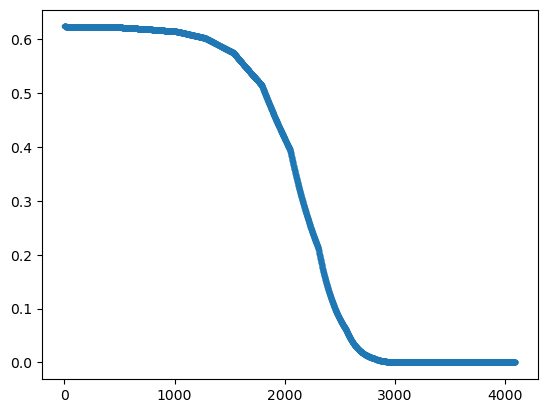

In [42]:
plt.plot(list(range(4096)), db2trans(volt2atten(dac2volt(np.array(list(range(4096)))))),'.')

In [ ]:
atten = volt2atten(dac2volt(4095))
#laser_current = 15uA ripple
laser_current_set_step = 500*u.mA  # 100 or 500mA step
levels = (diode.max_current-diode.threshold_current)/laser_current_set_step


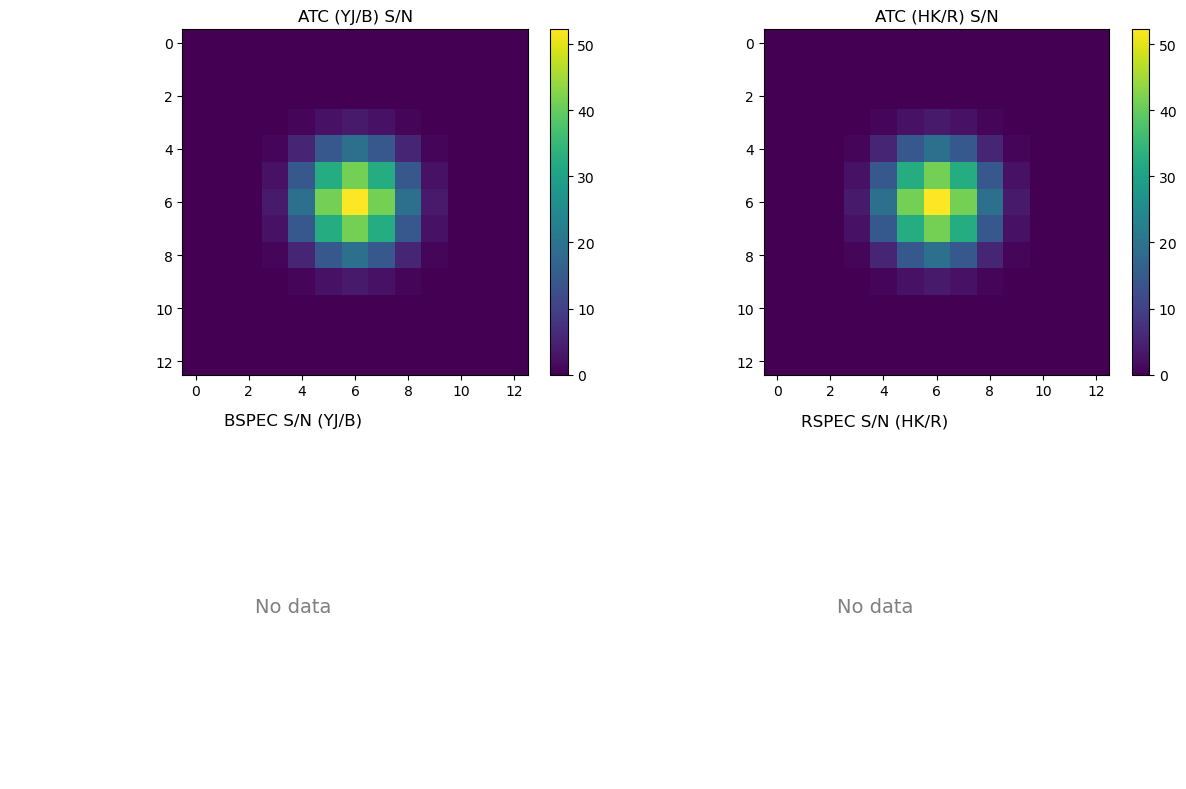

In [32]:
# 4-panel summary: Left column YJ/B, Right column HK/R. ATC on the top row.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


def show_no_data(ax, title):
    ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=14, color='gray')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


# Top-left: ATC (YJ/B)
ax = axes[0, 0]
if 'atc' in globals() and isinstance(obs.get(atc, None), type(obs.get(next(iter(obs.keys())), None))):
    data = getattr(obs.get(atc, None), 'snr', None)
    if data is not None:
        im0 = ax.imshow(data)
        ax.set_title('ATC (YJ/B) S/N')
        plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
    else:
        show_no_data(ax, 'ATC (YJ/B) S/N')
else:
    show_no_data(ax, 'ATC (YJ/B) S/N')

# Top-right: ATC (HK/R) — using same ATC data as a template if available
ax = axes[0, 1]
if 'atc' in globals() and isinstance(obs.get(atc, None), type(obs.get(next(iter(obs.keys())), None))):
    data = getattr(obs.get(atc, None), 'snr', None)
    if data is not None:
        im1 = ax.imshow(data)
        ax.set_title('ATC (HK/R) S/N')
        plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    else:
        show_no_data(ax, 'ATC (HK/R) S/N')
else:
    show_no_data(ax, 'ATC (HK/R) S/N')

# Bottom-left: BSPEC S/N (YJ/B)
ax = axes[1, 0]
bs_data = obs.get(bspec, None) if 'bspec' in globals() else None
if isinstance(bs_data, dict) and len(bs_data) > 0:
    for k, v in bs_data.items():
        if hasattr(v, 'sn'):
            ax.plot(v.sn(), label=f'Order: {k}')
    ax.set_title('BSPEC S/N (YJ/B)')
    ax.set_xlabel('Pixel / Sample')
    ax.set_ylabel('S/N')
    if len(ax.lines) > 0:
        ax.legend(fontsize=8)
    else:
        show_no_data(ax, 'BSPEC S/N (YJ/B)')
else:
    show_no_data(ax, 'BSPEC S/N (YJ/B)')

# Bottom-right: RSPEC S/N (HK/R)
ax = axes[1, 1]
rs_data = obs.get(rspec, None) if 'rspec' in globals() else None
if isinstance(rs_data, dict) and len(rs_data) > 0:
    for k, v in rs_data.items():
        if hasattr(v, 'sn'):
            ax.plot(v.sn(), label=f'Order: {k}')
    ax.set_title('RSPEC S/N (HK/R)')
    ax.set_xlabel('Pixel / Sample')
    ax.set_ylabel('S/N')
    if len(ax.lines) > 0:
        ax.legend(fontsize=8)
    else:
        show_no_data(ax, 'RSPEC S/N (HK/R)')
else:
    show_no_data(ax, 'RSPEC S/N (HK/R)')

plt.tight_layout()


In [33]:
paths = lp.find_all_paths(s_2330.port("out"), atc.port("in"))
print(f'\nATC 2330: {lp.path_curve(paths[0])(2330):.2g}')
for x in paths[0]:
    print(f'{repr(x)} (Trans: {x.tcurve(2330):.2g})')

paths = lp.find_all_paths(s_2330.port("out"), pd_hk.port("in"))
print(f'\nPD 2330: {lp.path_curve(paths[0])(2330):.2g}')
for x in paths[0]:
    print(f'{repr(x)} (Trans: {x.tcurve(2330):.2g})')


# Photodiode summary: print signal and S/N for YJ and HK
def _print_pd_summary(label, det, unit=u.mV):
    d = obs.get(det, None)
    if d is None:
        print(f'{label}: No data')
        return
    sig = getattr(d, 'signal', None)
    snr = getattr(d, 'snr', None)
    # Signal
    if sig is not None:
        try:
            sig_fmt = sig.to(unit)
        except Exception:
            sig_fmt = sig
        try:
            print(f'{label} signal: {sig_fmt:.3g}')
        except Exception:
            print(f'{label} signal: {sig_fmt}')
    else:
        print(f'{label} signal: N/A')
    # S/N
    if snr is not None:
        try:
            snr_val = np.nanmax(snr) if np.ndim(snr) > 0 else snr
        except Exception:
            snr_val = snr
        try:
            print(f'{label} S/N: {snr_val:.3g}')
        except Exception:
            print(f'{label} S/N: {snr_val}')
    else:
        print(f'{label} S/N: N/A')


_print_pd_summary('PD YJ', pd_yj)
_print_pd_summary('PD HK', pd_hk)



ATC 2330: 5.3e-12
LD2330.out->jumper_2330.in (Trans: 1)
jumper_2330.in->jumper_2330.out (Trans: 0.31)
jumper_2330.out->att_2330.in (Trans: 1)
att_2330.in->att_2330.out (Trans: 0.5)
att_2330.out->wdm_hk.in2 (Trans: 1)
wdm_hk.in2->wdm_hk.out (Trans: 0.25)
wdm_hk.out->sw26_hk_fei.C_in (Trans: 1)
sw26_hk_fei.C_in->sw26_hk_fei.B_out (Trans: 1)
sw26_hk_fei.B_out->fib_hk_fei.in (Trans: 1)
fib_hk_fei.in->fib_hk_fei.out (Trans: 0.71)
fib_hk_fei.out->beam_fei_in.in3 (Trans: 1)
beam_fei_in.in3->beam_fei_in.out (Trans: 1)
beam_fei_in.out->fei_pre_losses.A_in (Trans: 1)
fei_pre_losses.A_in->fei_pre_losses.B_out (Trans: 0.9)
fei_pre_losses.B_out->atc_dichroic_selector.A_in (Trans: 1)
atc_dichroic_selector.A_in->atc_dichroic_selector.B_out (Trans: 2.2e-10)
atc_dichroic_selector.B_out->ATC.in (Trans: 1)

PD 2330: 4e-06
LD2330.out->jumper_2330.in (Trans: 1)
jumper_2330.in->jumper_2330.out (Trans: 0.31)
jumper_2330.out->att_2330.in (Trans: 1)
att_2330.in->att_2330.out (Trans: 0.5)
att_2330.out->wdm_hk.

In [29]:
tc = lp.path_curve(lp.find_all_paths(s_2330.port("out"), pd_hk.port("in"))[0])
old_2330_value = .12*1.0*.98*.8*3.2e-4*.97*.75
tc(2330), old_2330_value

(<Quantity 3.9510499e-06>, 2.1901824e-05)

In [ ]:
readout_rates = {'1a-d_2a-g':    {'backward_atc': u.s/6, 'forward_atc': u.s/10},
                 '3a-d':         {'forward_bspec': u.s/20, 'forward_atc': u.s/10},
                 '3e-f':         {'forward_bspec': u.s/20, 'forward_atc': u.s/6},
                 '4a-d_7ab_8ab': {'forward_rfemto': u.s/20, 'forward_bfemto': u.s/20, 'forward_atc': u.s/6},
                 '5ab_6ab':      {'forward_rspec': u.s/20, 'forward_atc': u.s/6},
                 '4e-f_8c-e':    {'forward_rfemto': u.s/20, 'forward_bfemto': u.s/20, 'forward_atc': u.s/6},
                 '6c-e':         {'forward_rspec': u.s/20, 'forward_atc': u.s/6}
                 }


attenuations = {'1a-d_2a-g': {1430: {'backward':1e-10,
                                     'forward':1e-10}},
                '3a-d': {1028: 1e-9, 1430: 1e-10},
                '3e-f': {1270: 1e-7},
                '4a-d_7ab_8ab': {1028: 5e-8,
                                 1510: 5e-4,
                                 2330: 5e-4 },
                '5ab_6ab': {1430: 1e-10,
                            1510: 1e-8,
                            2330: 5e-8},
                '4e-f_8c-e': {'vortex_dark': {1270: 1e-4, 2330: 5e-1},
                              'vortex':{1270: 1e-7, 2330:1e-3}},
                '6c-e': {2330: 1e-7}
                }


# Cfg1 a-d Retro and 2a-g Forward
texp=readout_rates['1a-d_2a-g']
attens=attenuations['1a-d_2a-g']

diodes = [atc_diode]
fei_routes = ['backward_atc']
coupling_key = {'backward_atc':'unity','forward_atc':'unity'}
detectors = {'backward_atc':atc, 'forward_atc':atc}


# Cfg3 a-d
diodes = [atc_diode, forward_y_diode]
fei_routes = ['forward_atc', 'forward_bfocus']
coupling_key = {'forward_atc':'unity', 'forward_bfocus':'normal'}
detectors = {'forward_atc':atc, 'forward_bfocus':bspec}

texp=readout_rates['3a-d']
attens=attenuations['3a-d']


# Cfg3 e-f
diodes = [ forward_j_diode]
fei_routes = ['forward_atc','forward_bfocus']
coupling_key = {'forward_atc':1e-4, 'forward_bfocus':'vortex_dark'}
detectors = {'forward_atc':atc, 'forward_bfocus':bspec}

texp=readout_rates['3e-f']
attens=attenuations['3e-f']



# Cfg 4a-d, 7ab, 8ab
diodes = [forward_y_diode]
fei_routes = ['forward_atc', 'forward_bfocus']
coupling_key = {'forward_atc':1e-4, 'forward_bfocus':'normal', 'forward_rfocus':'normal'}
detectors = {'forward_atc':atc, 'forward_bfocus':bfemto, 'forward_rfocus':rfemto}

texp=readout_rates['4a-d_7ab_8ab']
attens=attenuations['4a-d_7ab_8ab']


# Cfg7&8
diodes = [forward_h_diode, forward_k_diode]

# Cfg5ab Cfg6ab
diodes = [atc_diode, forward_h_diode]
fei_routes = ['forward_atc', 'forward_rfocus']
coupling_key = {'forward_atc':1e-2, 'forward_rfocus':'normal'}
detectors = {'forward_atc':atc, 'forward_rfocus':rspec}

attens = attenuations['5ab_6ab']
texp = readout_rates['5ab_6ab']

# Cfg6ab
diodes = [atc_diode, forward_k_diode]


# Cfg 4e-f, 8cde
diodes = [forward_j_diode, forward_k_diode]
fei_routes = ['forward_atc', 'forward_bfocus', 'forward_rfocus']
coupling_key = {'forward_atc':1e-7, 'forward_bfocus':'vortex_dark', 'forward_rfocus':'vortex_dark'}
detectors = {'forward_atc':atc, 'forward_bfocus':bfemto, 'forward_rfocus':rfemto}

texp = readout_rates['4e-f_8c-e']
attens = attenuations['4e-f_8c-e']['vortex_dark']

# Cfg 4e-f 8cde Peak

coupling_key.update({'forward_bfocus': 'vortex', 'forward_rfocus':'vortex'})
attens = attenuations['4e-f_8c-e']['vortex']


# Cfg6c-e
diodes = [forward_k_diode]
fei_routes = ['forward_atc', 'forward_rfocus']
coupling_key = {'forward_atc': 1e-4, 'forward_rfocus': 'vortex_dark'}

detectors = {'forward_atc': atc, 'forward_rfocus': rspec}

attens = attenuations['6c-e']
texp = readout_rates['6c-e']

#Cfg 6c-e Peak
coupling_key = {'forward_atc': 1e-4, 'forward_rfocus': 'vortex'}

